# Distributed Signal Processing Course Project made by: Pablo Bakker and Ines Dos Reis

In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from utils import *

### For a fixed communication radius check what the number of nodes is needed


Connectivity experiment with communication radius r = 25 m
Number of Monte Carlo trials per n: 500
-----------------------------------------------------------------
n =  25 | P(connected) = 0.110 | avg degree = 3.75
n =  36 | P(connected) = 0.438 | avg degree = 5.52
n =  49 | P(connected) = 0.810 | avg degree = 7.54
n =  64 | P(connected) = 0.930 | avg degree = 9.85
n =  81 | P(connected) = 0.974 | avg degree = 12.51
n = 100 | P(connected) = 0.996 | avg degree = 15.51
n = 121 | P(connected) = 1.000 | avg degree = 18.74
n = 144 | P(connected) = 1.000 | avg degree = 22.43
n = 169 | P(connected) = 1.000 | avg degree = 26.30
Minimum n reaching 99% connectivity: 100


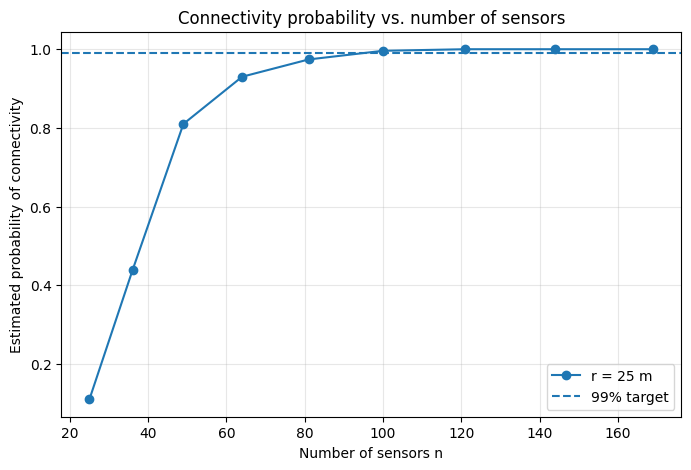

In [ ]:
# Parameters:
AREA_LENGTH = 100
COMM_RADIUS = 25         
n_values = [25, 36, 49, 64, 81, 100, 121, 144, 169]
n_trials = 500
target_probability = 0.99

# Connectivity sensitivity experiment
results = estimate_connectivity_probability(n_values=n_values, comm_radius=COMM_RADIUS, area_length=AREA_LENGTH, n_trials=n_trials)

print(f"\nConnectivity experiment with communication radius r = {COMM_RADIUS} m")
print(f"Number of Monte Carlo trials per n: {n_trials}")
print("-" * 65)
required_n = None
for row in results:
    print(
        f"n = {row['n']:3d} | "
        f"P(connected) = {row['connectivity_probability']:.3f} | "
        f"avg degree = {row['mean_average_degree']:.2f}"
    )
    if required_n is None and row["connectivity_probability"] >= target_probability:
        required_n = row["n"]
if required_n is not None:
    print(f"Minimum n reaching {target_probability:.0%} connectivity: {required_n}")
else:
    print(f"No tested n reached {target_probability:.0%} connectivity.")

# Plot 
plt.figure(figsize=(8, 5))
plt.plot([row["n"] for row in results], [row["connectivity_probability"] for row in results], marker="o", label=f"r = {COMM_RADIUS} m")
plt.axhline(target_probability, linestyle="--", label="99% target")
plt.xlabel("Number of sensors n")
plt.ylabel("Estimated probability of connectivity")
plt.title("Connectivity probability vs. number of sensors")
plt.grid(True, alpha=0.3)
plt.legend()
# plt.savefig('mc.png')
plt.show()

### Creating the sensor networks

Critical RGG radius for n=100: r_c = 30.35 m
Probability bound given by critical radius = 0.9999

Using communication radius r = 25.00 m
--- Random Geometric Graph ---
  nodes              : 100
  edges              : 706
  connected          : True
  average degree     : 14.12
  lambda_2 : 0.9888
  lambda_max : 0.0000

--- Regular Grid Graph (4-neighbour) ---
  nodes              : 100
  edges              : 180
  connected          : True
  average degree     : 3.60
  lambda_2 : 0.9970
  lambda_max : -0.0000



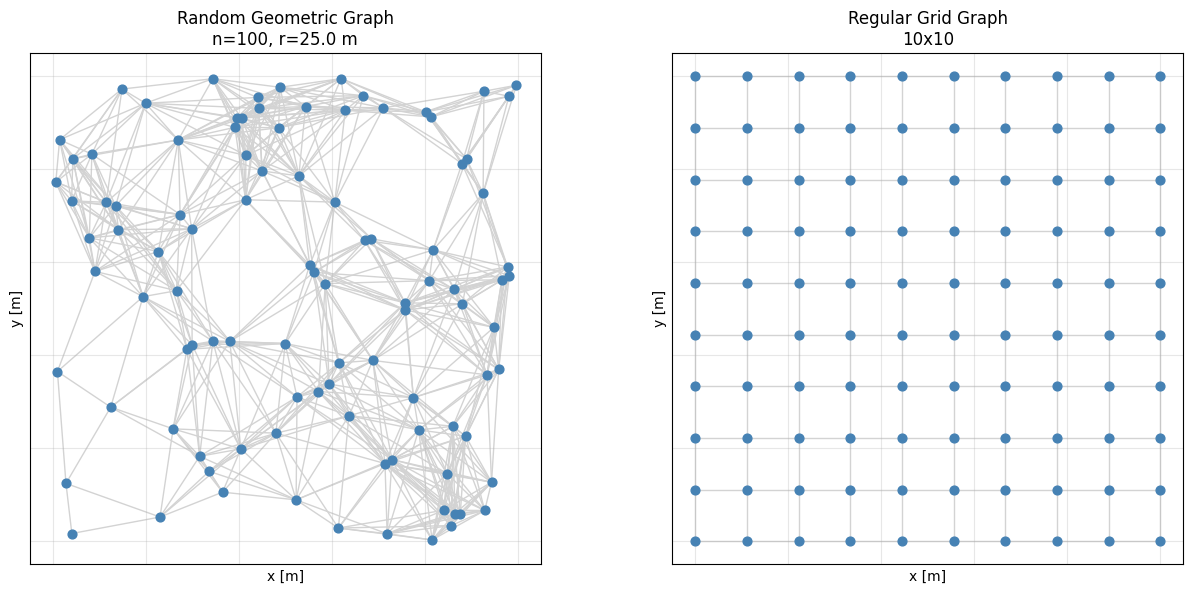

In [ ]:
# Parameters
N_SENSORS = 100 # From the experiment     
GRID_SIZE = 10  # sqrt(N_SENSORS)

# Compare theoretical bound for radius
r_c = critical_radius_rgg(N_SENSORS, AREA_LENGTH)
print(f"Critical RGG radius for n={N_SENSORS}: r_c = {r_c:.2f} m")
print(f'Probability bound given by critical radius = {1-1/N_SENSORS**2}\n')
print(f"Using communication radius r = {COMM_RADIUS:.2f} m")

# Build the graphs
G_rgg, pos_rgg = random_geometric_network(N_SENSORS, AREA_LENGTH, COMM_RADIUS, seed=0)
G_grid, pos_grid = grid_network(GRID_SIZE, AREA_LENGTH, neighbours="4")

# Get information aboiut the graphs
network_summary(G_rgg, name="Random Geometric Graph")
network_summary(G_grid, name="Regular Grid Graph (4-neighbour)")

# Plot the connectivity 
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_network(G_rgg, pos_rgg, f"Random Geometric Graph\nn={N_SENSORS}, r={COMM_RADIUS:.1f} m", axes[0])
plot_network(G_grid, pos_grid, f"Regular Grid Graph\n{GRID_SIZE}x{GRID_SIZE}", axes[1])
plt.tight_layout()
# plt.savefig("sensor_networks.png", dpi=110, bbox_inches="tight")
plt.show()

## Randomized Gossip

True average: 19.631939393635268
Final average estimate range: 19.63193645269602 19.63194248839691
Final relative error: 2.0675124122838142e-13


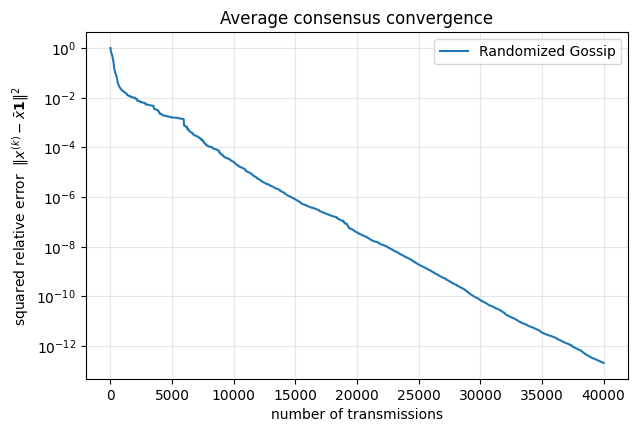

In [5]:
# Initial sensor measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())

# Run Gossip
x_random_gossip, errors_random_gossip, tx_random_gossip = randomized_gossip_average(G=G_rgg, x0=x0, n_iterations=20_000, packet_loss_prob=0.0, seed=2)

# Final metrics
print("True average:", np.mean(x0))
print("Final average estimate range:", x_random_gossip.min(), x_random_gossip.max())
print("Final relative error:", errors_random_gossip[-1])

# Plot convergence
plt.figure(figsize=(7, 4.5))
plt.semilogy(tx_random_gossip, np.clip(errors_random_gossip, 1e-16, None), label="Randomized Gossip")
plt.xlabel("number of transmissions")
plt.ylabel(r"squared relative error  $\|x^{(k)} - \bar x\mathbf{1}\|^2$")
plt.title("Average consensus convergence")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## Broadcast One-Way Gossip

True average: 19.631939393635268
Final average estimate range: 18.419691215135245 18.419691215135245
Final relative error: 0.08106173542456764


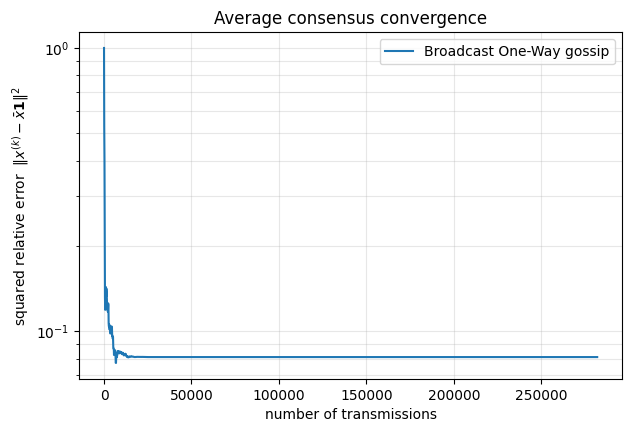

In [6]:
# Initial sensor measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())

# Run Gossip
x_bc_gossip, errors_bc_gossip, tx__bc_gossip = randomized_broadcast_gossip(G=G_rgg, x0=x0, n_iterations=20_000, packet_loss_prob=0.0, seed=2)

# Final metrics
print("True average:", np.mean(x0))
print("Final average estimate range:", x_bc_gossip.min(), x_bc_gossip.max())
print("Final relative error:", errors_bc_gossip[-1])

# Plot convergence
plt.figure(figsize=(7, 4.5))
plt.semilogy(tx__bc_gossip, np.clip(errors_bc_gossip, 1e-16, None), label="Broadcast One-Way gossip")
plt.xlabel("number of transmissions")
plt.ylabel(r"squared relative error  $\|x^{(k)} - \bar x\mathbf{1}\|^2$")
plt.title("Average consensus convergence")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## Sum-Weight Gossip

True average: 19.631939393635268
Final average estimate range: 19.631930479762477 19.63194869201465
Final relative error: 1.881980852647299e-12


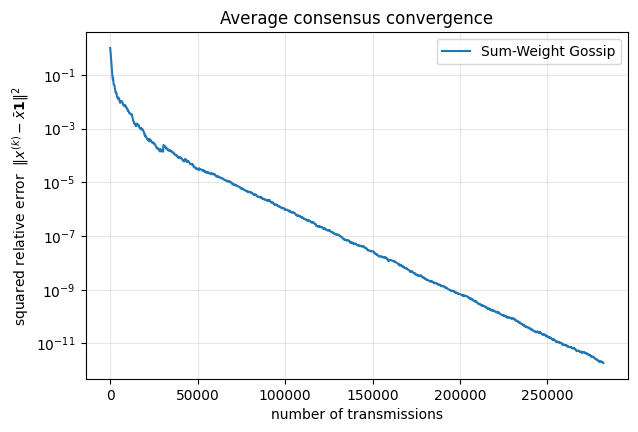

In [7]:
# Initial sensor measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())

# Run Gossip
x_sw_gossip, errors_sw_gossip, tx_sw_gossip = sum_weight_broadcast(G=G_rgg, x0=x0, n_iterations=20_000, packet_loss_prob=0.0, seed=2)

# Final metrics
print("True average:", np.mean(x0))
print("Final average estimate range:", x_sw_gossip.min(), x_sw_gossip.max())
print("Final relative error:", errors_sw_gossip[-1])

# Plot convergence
plt.figure(figsize=(7, 4.5))
plt.semilogy(tx_sw_gossip, np.clip(errors_sw_gossip, 1e-16, None), label="Sum-Weight Gossip")
plt.xlabel("number of transmissions")
plt.ylabel(r"squared relative error  $\|x^{(k)} - \bar x\mathbf{1}\|^2$")
plt.title("Average consensus convergence")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## PDMM

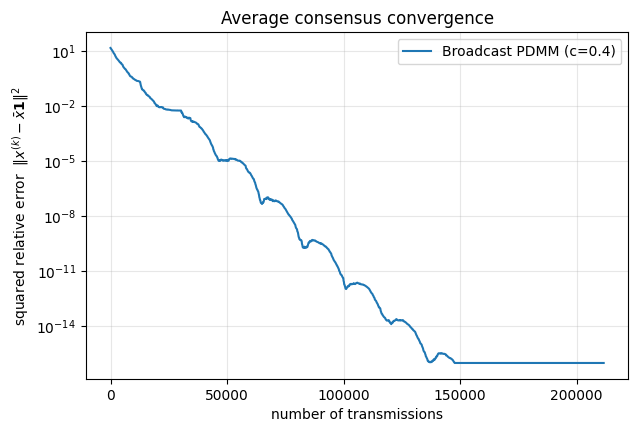

In [8]:
# Initial sensor measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())

# Run PDMM
x_pdmm, err_pdmm, tx_pdmm = pdmm_average_broadcast(G_rgg, x0, n_iterations=15_000, c=0.4, seed=2)

# Plot
plt.figure(figsize=(7, 4.5))
plt.semilogy(tx_pdmm, np.clip(err_pdmm, 1e-16, None), label="Broadcast PDMM (c=0.4)")
plt.xlabel("number of transmissions")
plt.ylabel(r"squared relative error  $\|x^{(k)} - \bar x\mathbf{1}\|^2$")
plt.title("Average consensus convergence")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

### Compare all of them on one plot

### Random Geometric Graph

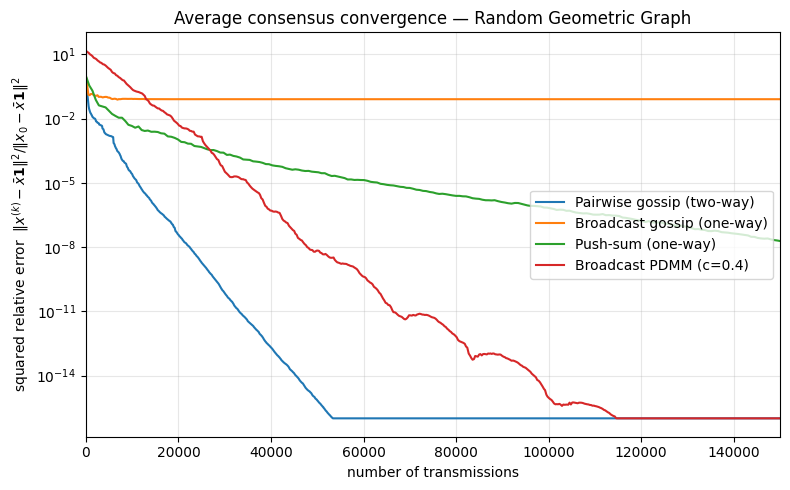

In [ ]:
# Initial measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())
EPS = 1e-16

# Run all four algorithms
x_pg, err_pg, tx_pg = randomized_gossip_average(G_rgg, x0, n_iterations=80_000, seed=2, track_every=50)
x_bg, err_bg, tx_bg = randomized_broadcast_gossip(G_rgg, x0, n_iterations=20_000, alpha=0.5, seed=2, track_every=20)
x_ps, err_ps, tx_ps = sum_weight_broadcast(G_rgg, x0, n_iterations=40_000, seed=0, track_every=50)[:3]
x_pd, err_pd, tx_pd = pdmm_average_broadcast(G_rgg, x0, n_iterations=15_000, c=0.4, seed=0, track_every=20)

# Plot
plt.figure(figsize=(8, 5))
plt.semilogy(tx_pg, np.clip(err_pg, EPS, None), label="Pairwise gossip (two-way)")
plt.semilogy(tx_bg, np.clip(err_bg, EPS, None), label="Broadcast gossip (one-way)")
plt.semilogy(tx_ps, np.clip(err_ps, EPS, None), label="Push-sum (one-way)")
plt.semilogy(tx_pd, np.clip(err_pd, EPS, None), label="Broadcast PDMM (c=0.4)")
plt.xlabel("number of transmissions")
plt.ylabel(r"squared relative error  $\|x^{(k)} - \bar x\mathbf{1}\|^2 / \|x_0 - \bar x\mathbf{1}\|^2$")
plt.title("Average consensus convergence — Random Geometric Graph")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim(0, 150_000)
plt.tight_layout()
# plt.savefig('avg_consensus_RGG.png')
plt.show()

### Grid Graph

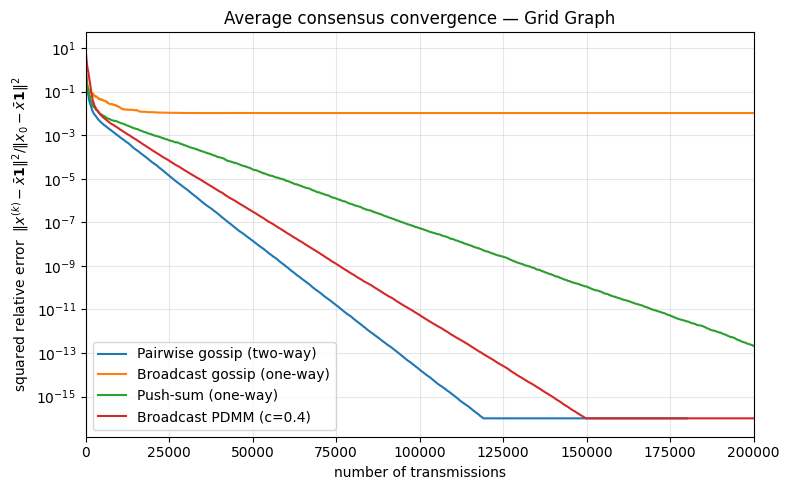

In [ ]:
# Initial measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_grid.number_of_nodes())
EPS = 1e-16

# Run all four algorithms
x_pg, err_pg, tx_pg = randomized_gossip_average(G_grid, x0, n_iterations=90_000, seed=2, track_every=50)
x_bg, err_bg, tx_bg = randomized_broadcast_gossip(G_grid, x0, n_iterations=60_000, alpha=0.5, seed=2, track_every=20)
x_ps, err_ps, tx_ps = sum_weight_broadcast(G_grid, x0, n_iterations=60_000, seed=0, track_every=50)[:3]
x_pd, err_pd, tx_pd = pdmm_average_broadcast(G_grid, x0, n_iterations=60_000, c=0.4, seed=0, track_every=20)

# Plot
plt.figure(figsize=(8, 5))
plt.semilogy(tx_pg, np.clip(err_pg, EPS, None), label="Pairwise gossip (two-way)")
plt.semilogy(tx_bg, np.clip(err_bg, EPS, None), label="Broadcast gossip (one-way)")
plt.semilogy(tx_ps, np.clip(err_ps, EPS, None), label="Push-sum (one-way)")
plt.semilogy(tx_pd, np.clip(err_pd, EPS, None), label="Broadcast PDMM (c=0.4)")
plt.xlabel("number of transmissions")
plt.ylabel(r"squared relative error  $\|x^{(k)} - \bar x\mathbf{1}\|^2 / \|x_0 - \bar x\mathbf{1}\|^2$")
plt.title("Average consensus convergence — Grid Graph")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim(0, 200_000)
plt.tight_layout()
# plt.savefig('avg_consensus_grid.png')
plt.show()

## Look at effect of packet loss

### Random Geometric Graph

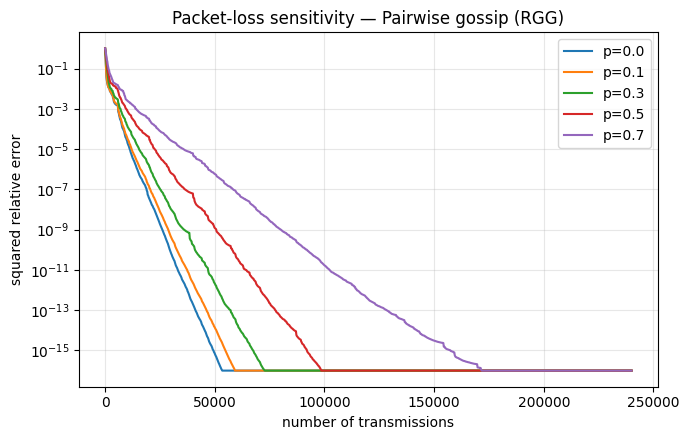

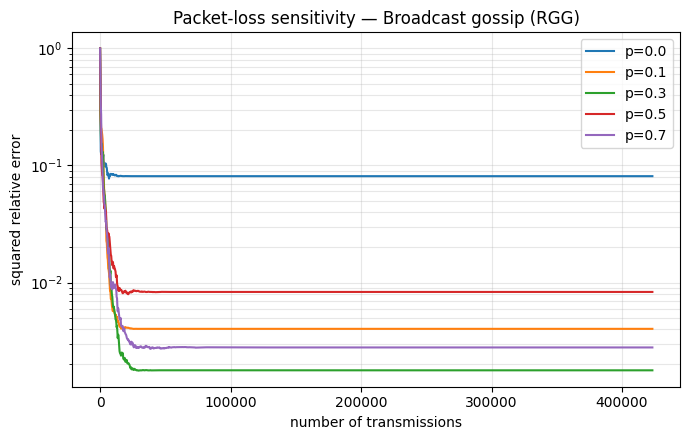

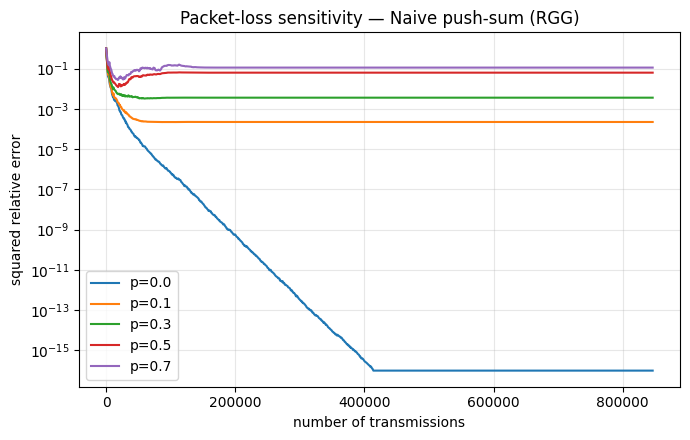

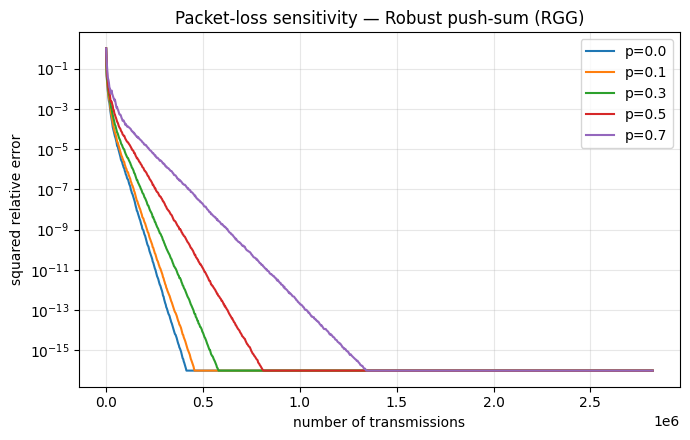

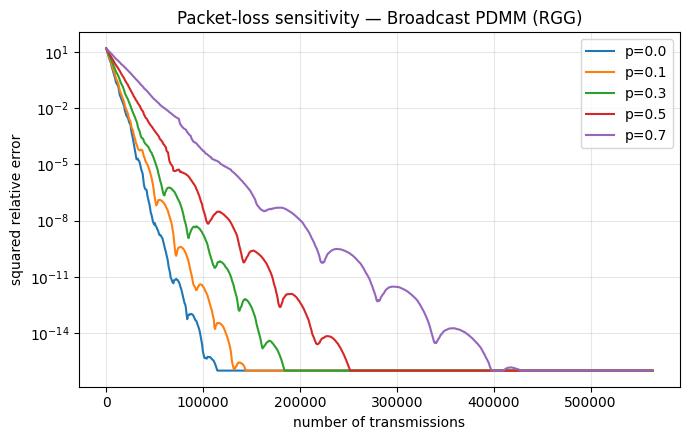

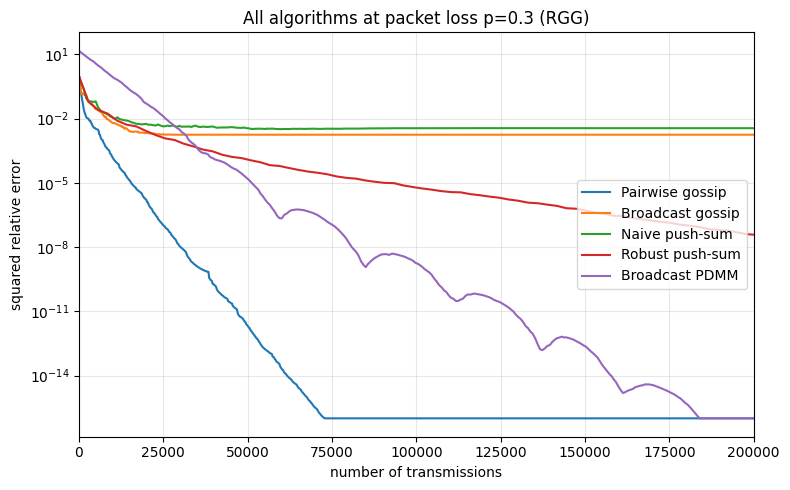

In [ ]:
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())
EPS = 1e-16
loss_rates = [0.0, 0.1, 0.3, 0.5, 0.7]

algos = {
    "Pairwise gossip":  lambda p: randomized_gossip_average(G_rgg, x0, n_iterations=120_000, packet_loss_prob=p, seed=2, track_every=100),
    "Broadcast gossip": lambda p: randomized_broadcast_gossip(G_rgg, x0, n_iterations=30_000, alpha=0.5, packet_loss_prob=p, seed=2, track_every=20),
    "Naive push-sum":   lambda p: sum_weight_broadcast(G_rgg, x0, n_iterations=60_000, packet_loss_prob=p, seed=0, track_every=50)[:3],
    "Robust push-sum":  lambda p: robust_sum_weight_broadcast(G_rgg, x0, n_iterations=200_000, packet_loss_prob=p, seed=0, track_every=200)[:3],
    "Broadcast PDMM":   lambda p: pdmm_average_broadcast(G_rgg, x0, n_iterations=40_000, c=0.4, packet_loss_prob=p, seed=0, track_every=50),
}

# Plot one separate figure per algorithm, curves = loss rates
for name, run in algos.items():
    plt.figure(figsize=(7, 4.5))
    for p in loss_rates:
        x, err, tx = run(p)
        plt.semilogy(tx, np.clip(err, EPS, None), label=f"p={p}")
    plt.xlabel("number of transmissions")
    plt.ylabel("squared relative error")
    plt.title(f"Packet-loss sensitivity — {name} (RGG)")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'{name}_packet_loss_png')
    plt.show()

# Plot all algorithms at one fixed loss rate
p_fixed = 0.3
plt.figure(figsize=(8, 5))
for name, run in algos.items():
    x, err, tx = run(p_fixed)
    plt.semilogy(tx, np.clip(err, EPS, None), label=name)
plt.xlabel("number of transmissions")
plt.ylabel("squared relative error")
plt.title(f"All algorithms at packet loss p={p_fixed} (RGG)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim(0, 200_000)
plt.tight_layout()
# plt.savefig('packet_loss_rgg.png')
plt.show()

### Grid Graph

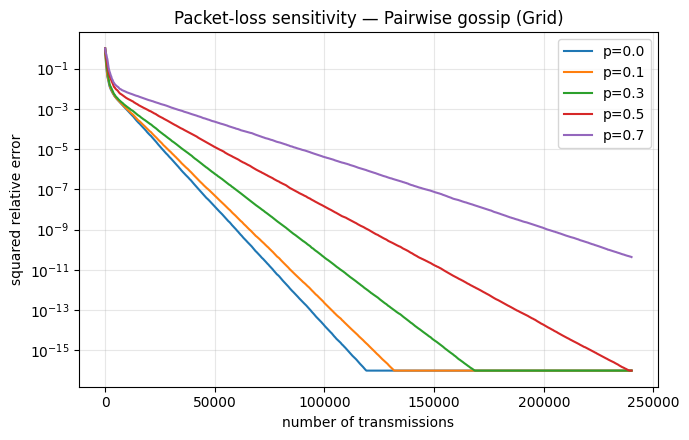

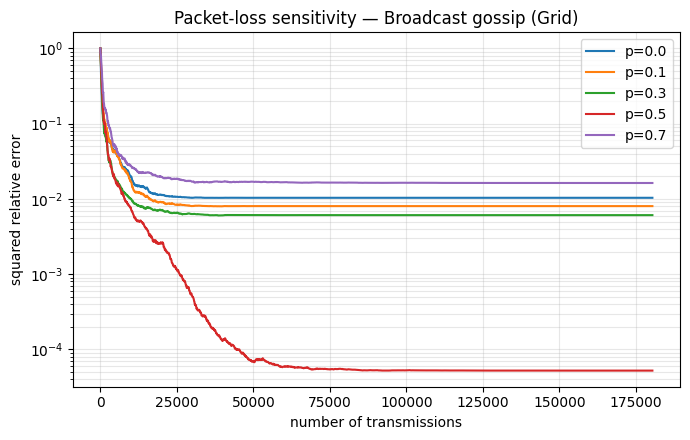

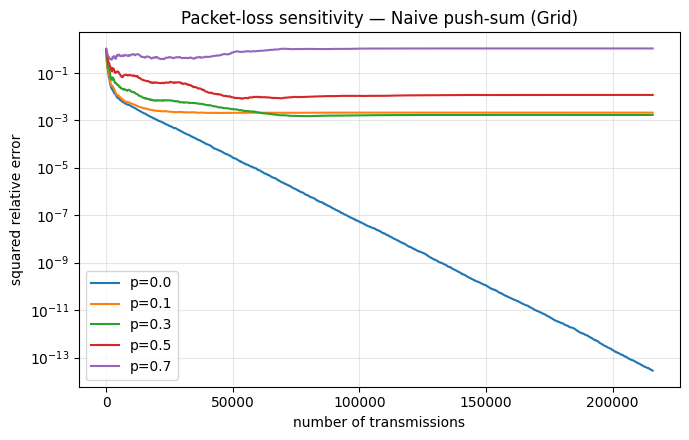

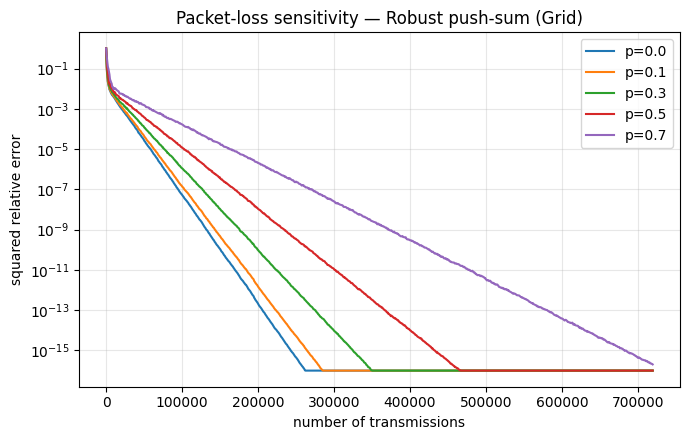

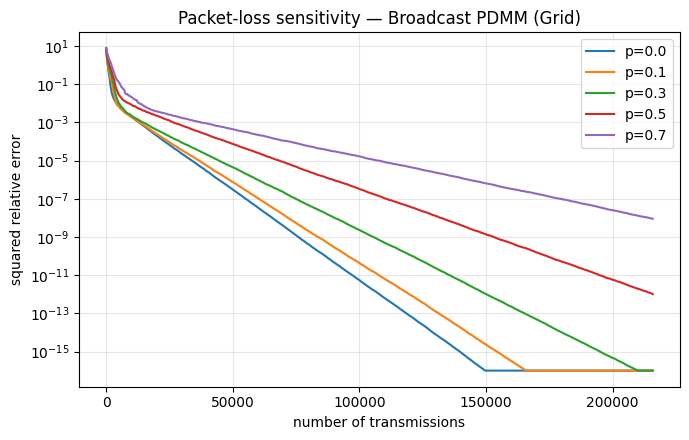

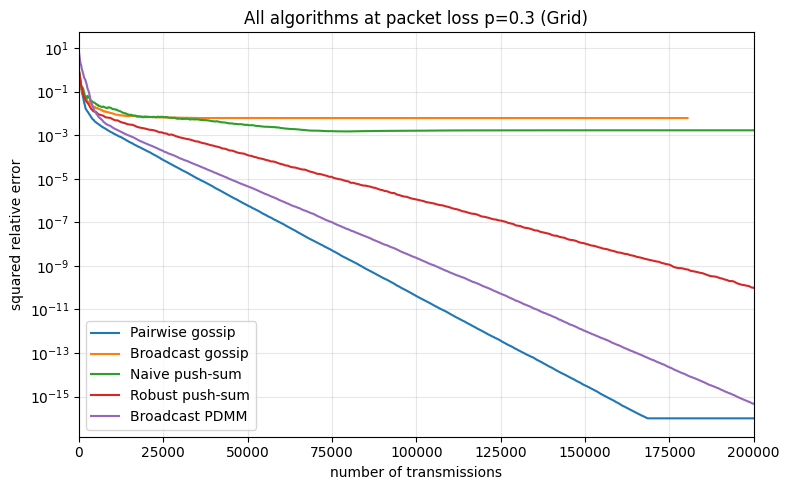

In [ ]:
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_grid.number_of_nodes())
EPS = 1e-16
loss_rates = [0.0, 0.1, 0.3, 0.5, 0.7]

algos = {
    "Pairwise gossip":  lambda p: randomized_gossip_average(G_grid, x0, n_iterations=120_000, packet_loss_prob=p, seed=2, track_every=100),
    "Broadcast gossip": lambda p: randomized_broadcast_gossip(G_grid, x0, n_iterations=50_000, alpha=0.5, packet_loss_prob=p, seed=2, track_every=20),
    "Naive push-sum":   lambda p: sum_weight_broadcast(G_grid, x0, n_iterations=60_000, packet_loss_prob=p, seed=0, track_every=50)[:3],
    "Robust push-sum":  lambda p: robust_sum_weight_broadcast(G_grid, x0, n_iterations=200_000, packet_loss_prob=p, seed=0, track_every=200)[:3],
    "Broadcast PDMM":   lambda p: pdmm_average_broadcast(G_grid, x0, n_iterations=60_000, c=0.4, packet_loss_prob=p, seed=0, track_every=50),
}

# Plot one separate figure per algorithm, curves = loss rates
for name, run in algos.items():
    plt.figure(figsize=(7, 4.5))
    for p in loss_rates:
        x, err, tx = run(p)
        plt.semilogy(tx, np.clip(err, EPS, None), label=f"p={p}")
    plt.xlabel("number of transmissions")
    plt.ylabel("squared relative error")
    plt.title(f"Packet-loss sensitivity — {name} (Grid)")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot all algorithms at one fixed loss rate
p_fixed = 0.3
plt.figure(figsize=(8, 5))
for name, run in algos.items():
    x, err, tx = run(p_fixed)
    plt.semilogy(tx, np.clip(err, EPS, None), label=name)
plt.xlabel("number of transmissions")
plt.ylabel("squared relative error")
plt.title(f"All algorithms at packet loss p={p_fixed} (Grid)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim(0, 200_000)
plt.tight_layout()
# plt.savefig('packet_loss_grid.png')
plt.show()

## Look at effect of quantization

### Random Geometric Graph

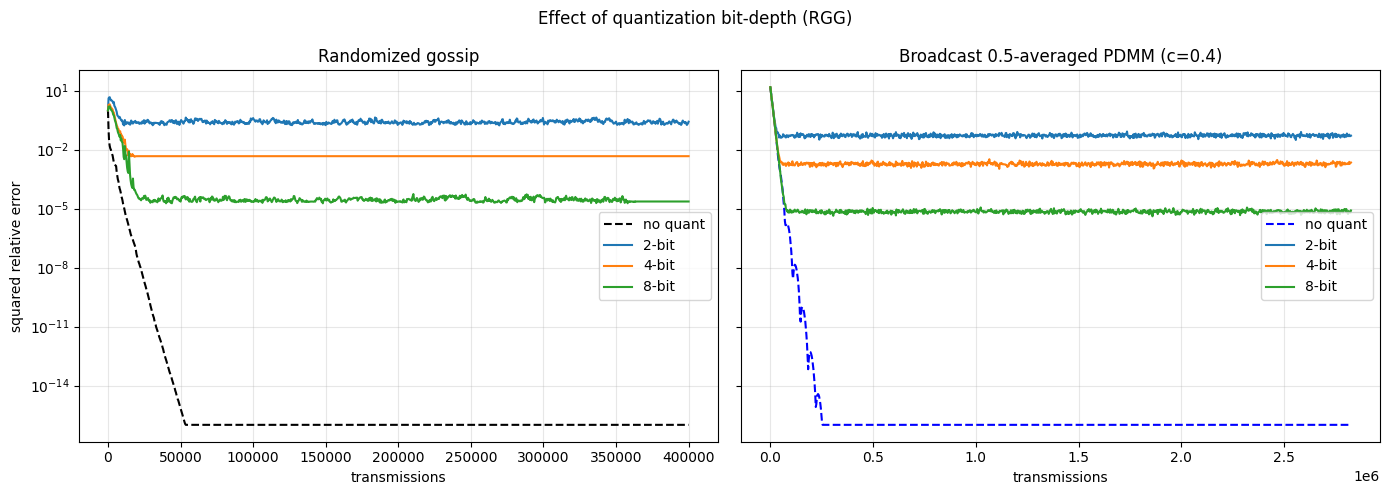

In [ ]:
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())
r_max = float(np.max(np.abs(x0 - np.mean(x0))))
alpha = 0.5
bits = [2, 4, 8]
N_TX = 200_000   # common x-range so curves reach their plateau

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gossip 
x, err, tx = randomized_gossip_average(G_rgg, x0, n_iterations=N_TX, seed=2, track_every=200)
ax1.semilogy(tx, np.clip(err, EPS, None), 'k--', label="no quant")
for B in bits:
    x, err, tx = randomized_gossip_quantized(G_rgg, x0, n_iterations=N_TX, n_bits=B, r_max=r_max, seed=2, track_every=200)
    ax1.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
ax1.set_title("Randomized gossip")
ax1.set_xlabel("transmissions"); ax1.set_ylabel("squared relative error")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# PDMM 
x, err, tx = pdmm_average_broadcast(G_rgg, x0, n_iterations=N_TX, c=0.4, seed=0, track_every=200, alpha=0.5)
ax2.semilogy(tx, np.clip(err, EPS, None), 'b--', label="no quant")
for B in bits:
    x, err, tx = pdmm_average_broadcast_quantized(G_rgg, x0, n_iterations=N_TX, c=0.4, n_bits=B, r_max=r_max, seed=0, track_every=200, alpha=alpha)
    ax2.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
ax2.set_title(f"Broadcast {alpha}-averaged PDMM (c=0.4)")
ax2.set_xlabel("transmissions")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.suptitle("Effect of quantization bit-depth (RGG)")
plt.tight_layout()
# plt.savefig('quantization_rgg.png')
plt.show()

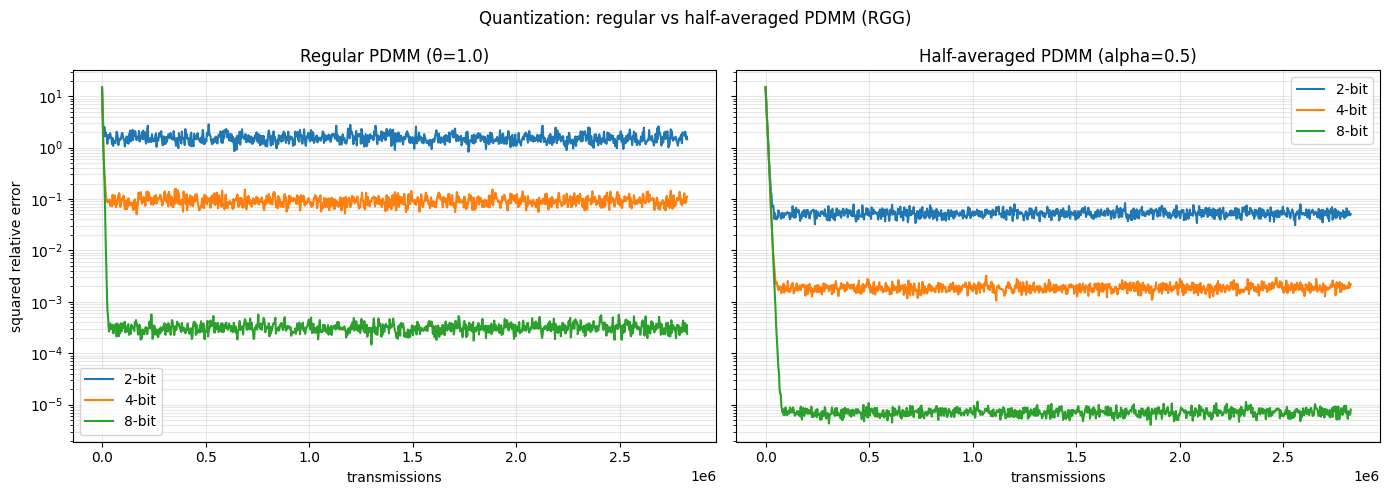

In [ ]:
# Compare half averaged PDMM with regular PDMM
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())
r_max = float(np.max(np.abs(x0 - np.mean(x0))))
bits = [2, 4, 8]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Regular PDMM (alpha=1.0)
for B in bits:
    x, err, tx = pdmm_average_broadcast_quantized(G_rgg, x0, n_iterations=200_000, c=0.4, n_bits=B, r_max=r_max, seed=0, track_every=200, alpha=1.0)
    ax1.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
ax1.set_title("Regular PDMM (θ=1.0)")
ax1.set_xlabel("transmissions"); ax1.set_ylabel("squared relative error")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# Half-averaged PDMM (alpha=0.5)
for B in bits:
    x, err, tx = pdmm_average_broadcast_quantized(G_rgg, x0, n_iterations=200_000, c=0.4, n_bits=B, r_max=r_max, seed=0, track_every=200, alpha=0.5)
    ax2.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
ax2.set_title("Half-averaged PDMM (alpha=0.5)")
ax2.set_xlabel("transmissions")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.suptitle("Quantization: regular vs half-averaged PDMM (RGG)")
plt.tight_layout()
# plt.savefig('quannt_avg_comp.png')
plt.show()

### Grid Graph

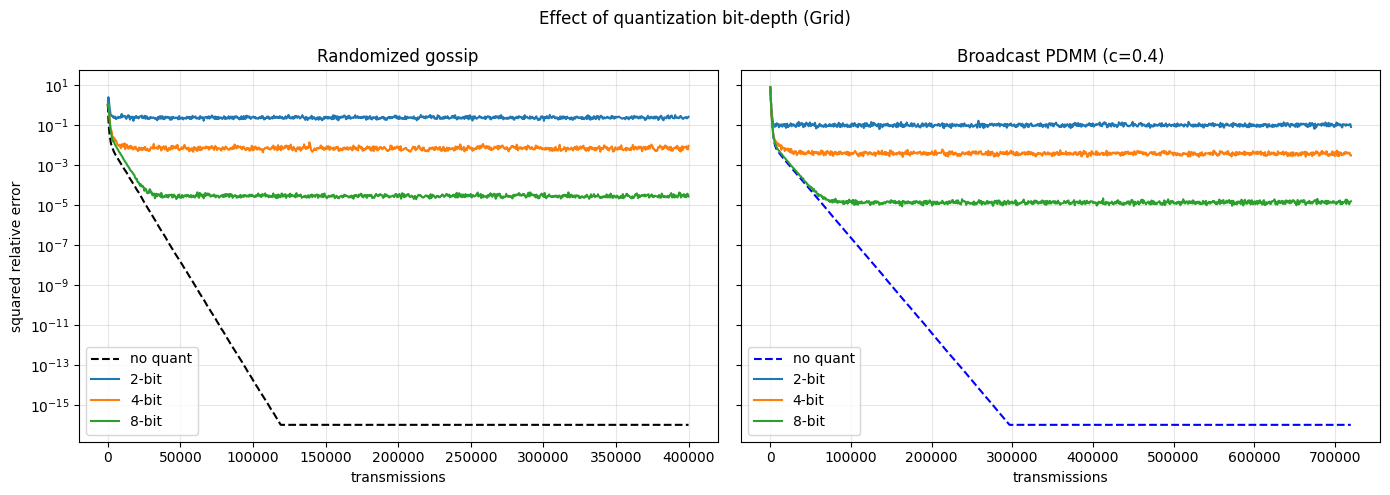

In [ ]:
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_grid.number_of_nodes())
r_max = float(np.max(np.abs(x0 - np.mean(x0))))
bits = [2, 4, 8]
N_TX = 200_000   # common x-range so curves reach their plateau

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gossip 
x, err, tx = randomized_gossip_average(G_grid, x0, n_iterations=N_TX, seed=2, track_every=200)
ax1.semilogy(tx, np.clip(err, EPS, None), 'k--', label="no quant")
for B in bits:
    x, err, tx = randomized_gossip_quantized(G_grid, x0, n_iterations=N_TX, n_bits=B, r_max=r_max, seed=2, track_every=200)
    ax1.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
ax1.set_title("Randomized gossip")
ax1.set_xlabel("transmissions"); ax1.set_ylabel("squared relative error")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

# PDMM 
x, err, tx = pdmm_average_broadcast(G_grid, x0, n_iterations=N_TX, c=0.4, seed=0, track_every=200, alpha=0.5)
ax2.semilogy(tx, np.clip(err, EPS, None), 'b--', label="no quant")
for B in bits:
    x, err, tx = pdmm_average_broadcast_quantized(G_grid, x0, n_iterations=N_TX, c=0.4, n_bits=B, r_max=r_max, seed=0, track_every=200, alpha=0.5)
    ax2.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
ax2.set_title("Broadcast PDMM (c=0.4)")
ax2.set_xlabel("transmissions")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.suptitle("Effect of quantization bit-depth (Grid)")
plt.tight_layout()
# plt.savefig('quant_grid.png')
plt.show()

### Look at effect of graph topology

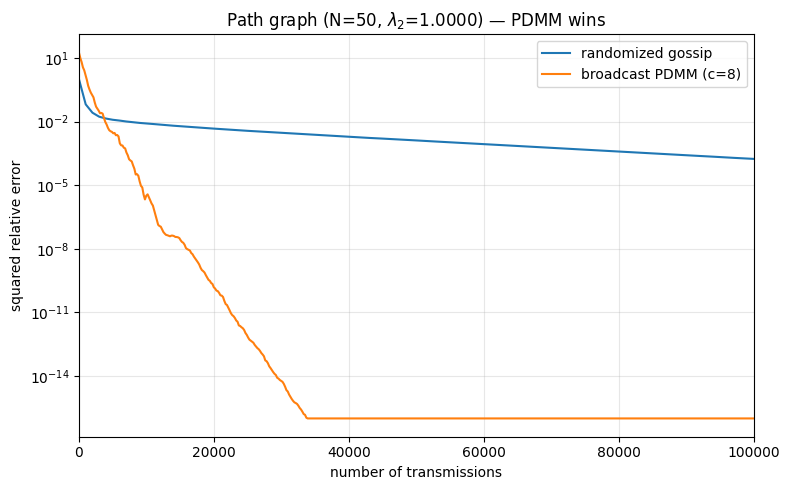

In [ ]:
G_path = nx.path_graph(50)
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(50)
EPS = 1e-16

x_g, err_g, tx_g = randomized_gossip_average(G_path, x0, n_iterations=100_000, seed=2, track_every=500)
x_p, err_p, tx_p = pdmm_average_broadcast(G_path, x0, n_iterations=55_000, c=8.0, seed=0, track_every=100)

lam2 = lambda2_W(G_path)

plt.figure(figsize=(8, 5))
plt.semilogy(tx_g, np.clip(err_g, EPS, None), label="randomized gossip")
plt.semilogy(tx_p, np.clip(err_p, EPS, None), label="broadcast PDMM (c=8)")
plt.xlabel("number of transmissions")
plt.ylabel("squared relative error")
plt.title(fr"Path graph (N=50, $\lambda_2$={lam2:.4f}) — PDMM wins")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim(0, 100_000)
plt.tight_layout()
# plt.savefig('path_graph.png')
plt.show()

## Introduce a few long-range links

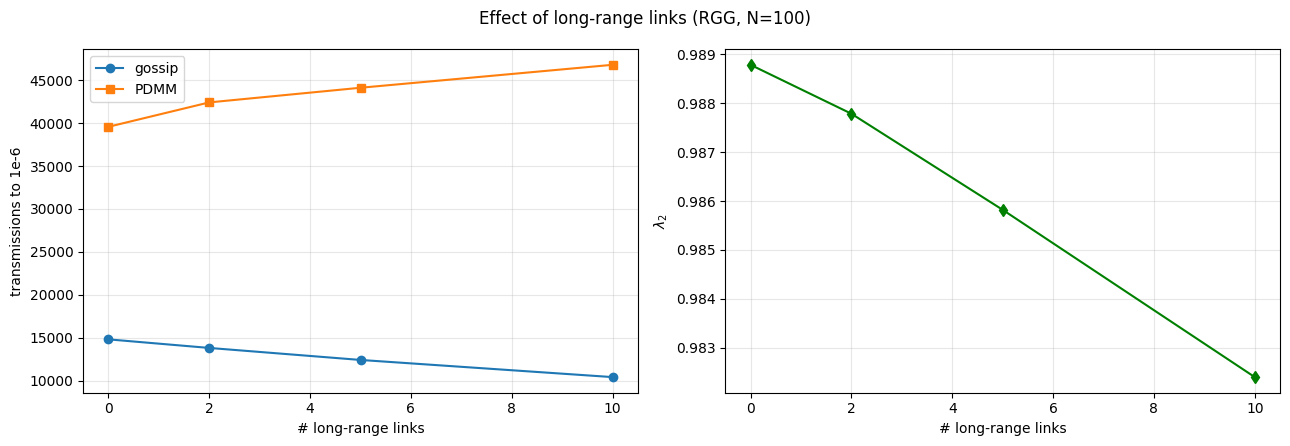

In [ ]:
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())

# Set how many long range links to trey
link_counts = [0, 2, 5, 10]

# Keep track of history
g_tx, p_tx, l2 = [], [], []

# Add long range links and run algorithms
for nl in link_counts:
    Gl = add_long_range_links(G_rgg, pos_rgg, nl, min_dist=50, seed=0) if nl else G_rgg
    _, eg, tg = randomized_gossip_average(Gl, x0, n_iterations=80_000, seed=2, track_every=100)
    _, ep, tp = pdmm_average_broadcast(Gl, x0, n_iterations=40_000, c=0.4, seed=0, track_every=100, alpha=1)
    g_tx.append(tx_to_tol(eg, tg, 1e-6))
    p_tx.append(tx_to_tol(ep, tp, 1e-6))
    l2.append(lambda2_W(Gl))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(link_counts, g_tx, 'o-', label="gossip"); ax[0].plot(link_counts, p_tx, 's-', label="PDMM")
ax[0].set_xlabel("# long-range links"); ax[0].set_ylabel("transmissions to 1e-6"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(link_counts, l2, 'd-', color="green") 
ax[1].set_xlabel("# long-range links")
ax[1].set_ylabel(r"$\lambda_2$")
ax[1].grid(alpha=0.3)
plt.suptitle("Effect of long-range links (RGG, N=100)")
plt.tight_layout()
# plt.savefig('long_range.png')
plt.show()

## Look at effect of number of nodes on convergence

N= 50: lam2(W)=0.990040  gossip tx=5200  pdmm tx=8143
N=100: lam2(W)=0.988788  gossip tx=8400  pdmm tx=31156
N=200: lam2(W)=0.994812  gossip tx=14000  pdmm tx=235840
N=300: lam2(W)=0.995174  gossip tx=11200  pdmm tx=855521


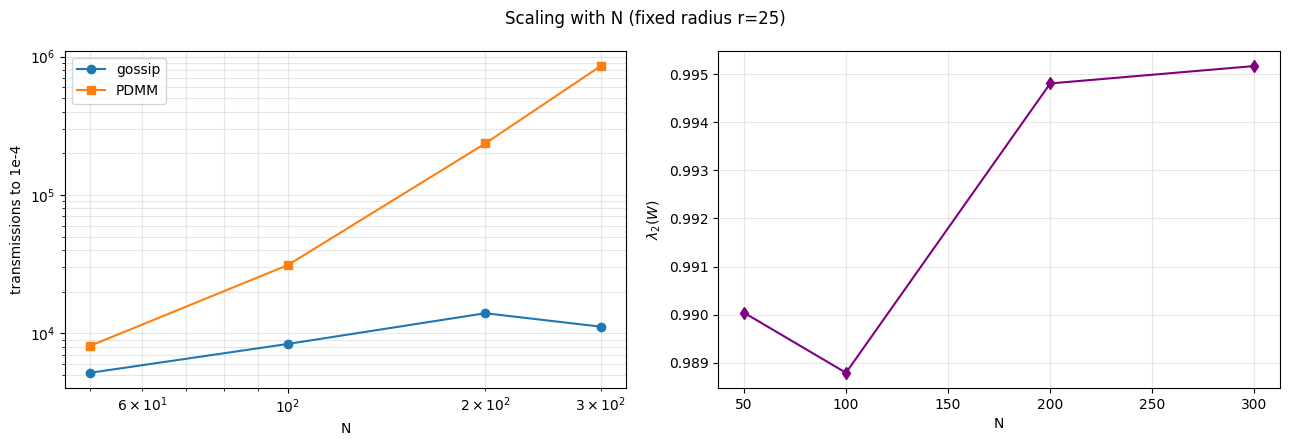

In [ ]:
# Reintroduce parameters
COMM_RADIUS = 25            
N_values = [50, 100, 200, 300]

# Keep track of history
g_scale = []
p_scale = []
w2 = []

# Run algorithms with different amount of nodes
for N in N_values:
    for trial in range(20):
        G, _ = random_geometric_network(N, 100, COMM_RADIUS, seed=trial)
        if nx.is_connected(G): break
    x0 = 20 + 5 * np.random.default_rng(1).standard_normal(N)
    _, eg, tg = randomized_gossip_average(G, x0, n_iterations=300_000, seed=2, track_every=200)
    _, ep, tp = pdmm_average_broadcast(G, x0, n_iterations=150_000, c=0.4, seed=0, track_every=200, alpha=1)
    g_scale.append(tx_to_tol(eg, tg, 1e-4))
    p_scale.append(tx_to_tol(ep, tp, 1e-4))
    w2.append(lambda2_W(G))
    print(f"N={N:3d}: lam2(W)={w2[-1]:.6f}  gossip tx={g_scale[-1]}  pdmm tx={p_scale[-1]}")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].loglog(N_values, g_scale, 'o-', label="gossip")
ax[0].loglog(N_values, p_scale, 's-', label="PDMM")
ax[0].set_xlabel("N"); ax[0].set_ylabel("transmissions to 1e-4"); ax[0].legend(); ax[0].grid(True, which="both", alpha=0.3)
ax[1].plot(N_values, w2, 'd-', color="purple")
ax[1].set_xlabel("N"); ax[1].set_ylabel(r"$\lambda_2(W)$"); ax[1].grid(alpha=0.3)
plt.suptitle(f"Scaling with N (fixed radius r={COMM_RADIUS})")
plt.tight_layout()
# plt.savefig('N_nodes.png')
plt.show()

## Median PDMM

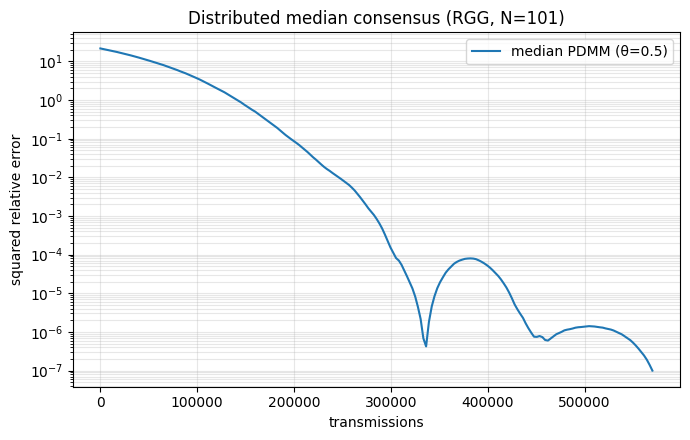

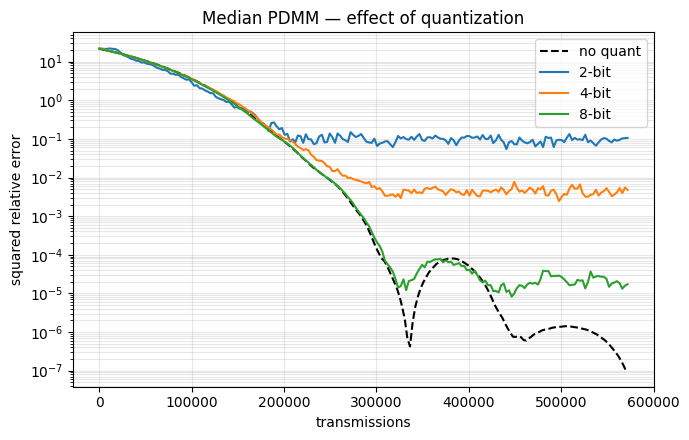

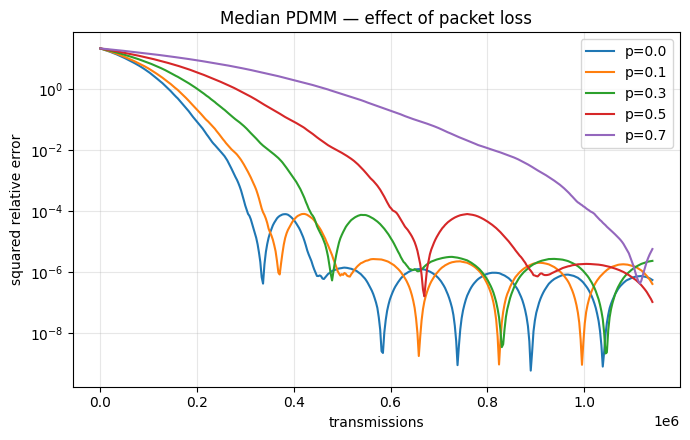

In [ ]:
# Setup with odd N for unique median
for trial in range(10):
    G_med, pos_med = random_geometric_network(101, 100, 25, seed=trial)
    if nx.is_connected(G_med): break
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(101)
r_max = float(np.max(np.abs(x0 - np.median(x0))))


# Regular problem convergence 
plt.figure(figsize=(7, 4.5))
x, err, tx = pdmm_median_broadcast(G_med, x0, n_iterations=40_000, c=0.4, seed=0, track_every=200, alpha=0.5)
plt.semilogy(tx, np.clip(err, EPS, None), label="median PDMM (θ=0.5)")
plt.xlabel("transmissions"); plt.ylabel("squared relative error")
plt.title("Distributed median consensus (RGG, N=101)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('median_pdmm_consensu.png')
plt.show()

# Quantization effect
plt.figure(figsize=(7, 4.5))
x, err, tx = pdmm_median_broadcast(G_med, x0, n_iterations=40_000, c=0.4, seed=0, track_every=200, alpha=0.5)
plt.semilogy(tx, np.clip(err, EPS, None), 'k--', label="no quant")
for B in [2, 4, 8]:
    x, err, tx = pdmm_median_quantized(G_med, x0, n_iterations=40_000, c=0.4, n_bits=B, r_max=r_max, seed=0, track_every=200, alpha=0.5)
    plt.semilogy(tx, np.clip(err, EPS, None), label=f"{B}-bit")
plt.xlabel("transmissions"); plt.ylabel("squared relative error")
plt.title("Median PDMM — effect of quantization")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('median_quant.png')
plt.show()


# Packet loss effect
plt.figure(figsize=(7, 4.5))
for p in [0.0, 0.1, 0.3, 0.5, 0.7]:
    x, err, tx = pdmm_median_broadcast(G_med, x0, n_iterations=80_000, c=0.4, packet_loss_prob=p, seed=0, track_every=200, alpha=0.5)
    plt.semilogy(tx, np.clip(err, EPS, None), label=f"p={p}")
plt.xlabel("transmissions"); plt.ylabel("squared relative error")
plt.title("Median PDMM — effect of packet loss")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig('packet_loss_median.png')
plt.show()